# 04 — Evaluation and post-processing

This notebook evaluates the cosine-similarity cell-type assignments from Notebook 03 using:

1. Marker-gene enrichment by predicted cell type  
2. Confidence and margin scoring  
3. Spatial confidence visualization over the Cellpose mask  
4. Flagged-cell overlay  
5. Optional experimental re-segmentation of low-confidence cells  

This version is updated for the new Xenium breast cancer dataset and the revised file layout.

**Inputs**
- `data/cell_expression_aligned.csv`
- `outputs/prototypes_normalized.csv`
- `outputs/cell_type_predictions.csv`
- `outputs/cosine_similarity_matrix.csv`
- `data/masks_center.npy`
- `data/morphology_focus/*.ome.tif`
- `data/assigned_transcripts_crop.csv`

**Outputs**
- `outputs/cell_type_predictions_refined.csv`
- `outputs/marker_gene_heatmap.png`
- `outputs/margin_histogram.png`
- `outputs/confidence_map.png`
- `outputs/flagged_cells_overlay.png`
- `outputs/before_after_postprocessing.png`


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tifffile as tiff

from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# Cellpose is only needed for the optional re-segmentation section.
# If Cellpose is unavailable, the core evaluation sections still run.
try:
    from cellpose import models
    CELLPOSE_AVAILABLE = True
except Exception as e:
    CELLPOSE_AVAILABLE = False
    print("Cellpose import failed. Optional re-segmentation will be skipped.")
    print(e)

## Config

In [2]:
# =========================
# Config
# =========================

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

CELL_EXPR_PATH = DATA_DIR / "cell_expression_aligned.csv"
PROTOTYPES_PATH = OUTPUT_DIR / "prototypes_normalized.csv"
PREDICTIONS_PATH = OUTPUT_DIR / "cell_type_predictions.csv"
SIM_MATRIX_PATH = OUTPUT_DIR / "cosine_similarity_matrix.csv"
MASK_PATH = DATA_DIR / "masks_center.npy"
ASSIGNED_TRANSCRIPTS_PATH = DATA_DIR / "assigned_transcripts_crop.csv"

MORPHOLOGY_DIR = DATA_DIR / "morphology_focus"

REFINED_PATH = OUTPUT_DIR / "cell_type_predictions_refined.csv"

# These should match Notebook 02.
CROP_SIZE = 512

# Confidence thresholds.
# A low best similarity means a cell does not strongly match any prototype.
CONFIDENCE_THRESHOLD = 0.5

# Margin = best score - second-best score.
# A low margin means assignment is ambiguous even if best score is not terrible.
MARGIN_THRESHOLD = 0.05

# Optional post-processing.
RUN_RESEGMENTATION = False
RETRY_DIAMETER = 20
PATCH_SIZE = 80

# Expected gene count from Notebook 01 after alignment.
EXPECTED_SHARED_GENES = 5054

MARKER_GENES = {
    "fibroblast": ["COL1A1", "COL1A2", "DCN", "LUM", "PDGFRA"],
    "myofibroblast": ["ACTA2", "TAGLN", "MYL9", "COL3A1"],
    "endothelial": ["PECAM1", "VWF", "KDR", "RAMP2", "ENG"],
    "pericyte": ["RGS5", "PDGFRB", "MCAM", "CSPG4"],
    "vascular_smooth_muscle": ["ACTA2", "MYH11", "TAGLN", "MYLK"],
    "cycling": ["MKI67", "TOP2A", "UBE2C", "CENPF"],
    "immune": ["PTPRC", "CD3D", "CD3E", "MS4A1", "LYZ"],
    "epithelial": ["EPCAM", "KRT8", "KRT18", "KRT19"],
}

## Helper functions

In [3]:
def require_file(path: Path, description: str):
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {description}: {path}\n"
            "Check the previous notebooks and path configuration."
        )


def find_first_morphology_image(morphology_dir: Path) -> Path:
    image_files = sorted(
        list(morphology_dir.glob("*.ome.tif")) +
        list(morphology_dir.glob("*.ome.tiff")) +
        list(morphology_dir.glob("*.tif")) +
        list(morphology_dir.glob("*.tiff"))
    )

    if len(image_files) == 0:
        raise FileNotFoundError(f"No TIFF images found in {morphology_dir}")

    return image_files[0]


def parse_cell_id(cell_id_like):
    """Convert 'cell_12' or 12 into integer 12."""
    try:
        return int(str(cell_id_like).replace("cell_", ""))
    except Exception:
        return None


def load_center_crop(image_path: Path, crop_size: int):
    with tiff.TiffFile(image_path) as tif:
        img = tif.pages[0].asarray()

    if img.ndim == 3:
        img = img[..., 0]

    h, w = img.shape
    start_y = h // 2 - crop_size // 2
    start_x = w // 2 - crop_size // 2

    crop = img[start_y:start_y + crop_size, start_x:start_x + crop_size].astype(float)
    crop_norm = (crop - crop.min()) / (crop.max() - crop.min() + 1e-8)

    return crop_norm, start_x, start_y


def savefig(name: str, dpi: int = 300):
    path = OUTPUT_DIR / name
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved → {path}")

## 1 · Load data

In [4]:
CELL_EXPR_PATH = OUTPUT_DIR / "cell_expression_aligned.csv"
PROTOTYPES_PATH = OUTPUT_DIR / "prototypes_normalized.csv"
PREDICTIONS_PATH = OUTPUT_DIR / "cell_type_predictions.csv"
SIM_MATRIX_PATH = OUTPUT_DIR / "cosine_similarity_matrix.csv"
MASK_PATH = DATA_DIR / "masks_center.npy"

require_file(CELL_EXPR_PATH, "cell expression matrix")
require_file(PROTOTYPES_PATH, "normalized prototypes")
require_file(PREDICTIONS_PATH, "cell type predictions")
require_file(SIM_MATRIX_PATH, "cosine similarity matrix")
require_file(MASK_PATH, "Cellpose mask")

cells = pd.read_csv(CELL_EXPR_PATH, index_col=0)
prototypes = pd.read_csv(PROTOTYPES_PATH, index_col=0)
predictions = pd.read_csv(PREDICTIONS_PATH, index_col=0)
sim_df = pd.read_csv(SIM_MATRIX_PATH, index_col=0)
masks = np.load(MASK_PATH)

print("Cells:", cells.shape)
print("Prototypes:", prototypes.shape)
print("Predictions:", predictions.shape)
print("Similarity matrix:", sim_df.shape)
print("Masks:", masks.shape)

if cells.shape[1] != prototypes.shape[1]:
    raise ValueError(
        f"Gene mismatch: cells have {cells.shape[1]} genes, "
        f"prototypes have {prototypes.shape[1]} genes."
    )

if cells.shape[1] != EXPECTED_SHARED_GENES:
    print(
        f"Warning: expected {EXPECTED_SHARED_GENES} genes, "
        f"but cell expression has {cells.shape[1]} genes."
    )

# Align objects to the same cell index.
common_cells = cells.index.intersection(predictions.index).intersection(sim_df.index)

if len(common_cells) == 0:
    raise ValueError(
        "No overlapping cell IDs among cells, predictions, and similarity matrix. "
        "Check index formatting, e.g. cell_1 vs 1."
    )

cells = cells.loc[common_cells].copy()
predictions = predictions.loc[common_cells].copy()
sim_df = sim_df.loc[common_cells].copy()

print("\nAfter cell-index alignment:")
print("Cells:", cells.shape)
print("Predictions:", predictions.shape)
print("Similarity matrix:", sim_df.shape)

print("\nPredicted cell type counts:")
print(predictions["predicted_cell_type"].value_counts())

Cells: (82, 5054)
Prototypes: (8, 5054)
Predictions: (82, 2)
Similarity matrix: (82, 8)
Masks: (512, 512)

After cell-index alignment:
Cells: (82, 5054)
Predictions: (82, 2)
Similarity matrix: (82, 8)

Predicted cell type counts:
predicted_cell_type
endothelial cell                          30
vein endothelial cell                     16
fibroblast                                12
pericyte                                   8
endothelial cell of artery                 5
myofibroblast cell                         5
endothelial cell of vascular tree          4
vascular associated smooth muscle cell     2
Name: count, dtype: int64


## 2 · Marker gene evaluation

In [5]:
available_markers = {}

for marker_group, genes in MARKER_GENES.items():
    present = [g for g in genes if g in cells.columns]
    missing = [g for g in genes if g not in cells.columns]

    if present:
        available_markers[marker_group] = present

    if missing:
        print(f"{marker_group}: markers not in panel/expression matrix: {missing}")

print("\nMarkers available for evaluation:")
for marker_group, genes in available_markers.items():
    print(f"{marker_group}: {genes}")

if len(available_markers) == 0:
    raise ValueError("No marker genes were found in the cell expression matrix.")

cells_with_pred = cells.copy()
cells_with_pred["predicted_cell_type"] = predictions["predicted_cell_type"]

rows = []

for marker_group, genes in available_markers.items():
    mean_expr = (
        cells_with_pred
        .groupby("predicted_cell_type")[genes]
        .mean()
        .mean(axis=1)
    )
    mean_expr.name = marker_group
    rows.append(mean_expr)

marker_df = pd.DataFrame(rows).fillna(0)

# Normalize each marker row to show relative enrichment.
marker_df_norm = marker_df.div(marker_df.max(axis=1) + 1e-9, axis=0)

print("Marker matrix:", marker_df.shape)
display(marker_df)
display(marker_df_norm)

fibroblast: markers not in panel/expression matrix: ['COL1A1', 'COL1A2']
myofibroblast: markers not in panel/expression matrix: ['ACTA2', 'TAGLN', 'COL3A1']
endothelial: markers not in panel/expression matrix: ['VWF', 'RAMP2']
vascular_smooth_muscle: markers not in panel/expression matrix: ['ACTA2', 'TAGLN']
immune: markers not in panel/expression matrix: ['PTPRC', 'LYZ']
epithelial: markers not in panel/expression matrix: ['KRT8', 'KRT18', 'KRT19']

Markers available for evaluation:
fibroblast: ['DCN', 'LUM', 'PDGFRA']
myofibroblast: ['MYL9']
endothelial: ['PECAM1', 'KDR', 'ENG']
pericyte: ['RGS5', 'PDGFRB', 'MCAM', 'CSPG4']
vascular_smooth_muscle: ['MYH11', 'MYLK']
cycling: ['MKI67', 'TOP2A', 'UBE2C', 'CENPF']
immune: ['CD3D', 'CD3E', 'MS4A1']
epithelial: ['EPCAM']
Marker matrix: (8, 8)


predicted_cell_type,endothelial cell,endothelial cell of artery,endothelial cell of vascular tree,fibroblast,myofibroblast cell,pericyte,vascular associated smooth muscle cell,vein endothelial cell
fibroblast,0.000000,0.0,0.0,0.166667,0.0,0.0000,0.0,0.000000
myofibroblast,0.000000,0.0,0.0,0.416667,1.2,0.0000,0.0,0.312500
endothelial,0.277778,0.0,0.0,0.277778,0.0,0.0000,0.0,0.395833
pericyte,0.000000,0.0,0.0,0.000000,0.0,0.0000,0.0,0.000000
vascular_smooth_muscle,0.250000,0.7,0.0,0.000000,0.2,0.3125,0.0,0.062500
cycling,0.166667,0.3,0.0,0.312500,0.0,0.0000,0.0,0.000000
immune,0.311111,0.0,0.0,0.000000,0.0,0.3750,0.0,0.083333
epithelial,0.000000,0.0,0.0,0.000000,0.0,0.0000,0.0,0.000000


predicted_cell_type,endothelial cell,endothelial cell of artery,endothelial cell of vascular tree,fibroblast,myofibroblast cell,pericyte,vascular associated smooth muscle cell,vein endothelial cell
fibroblast,0.000000,0.00,0.0,1.000000,0.000000,0.000000,0.0,0.000000
myofibroblast,0.000000,0.00,0.0,0.347222,1.000000,0.000000,0.0,0.260417
endothelial,0.701754,0.00,0.0,0.701754,0.000000,0.000000,0.0,1.000000
pericyte,0.000000,0.00,0.0,0.000000,0.000000,0.000000,0.0,0.000000
vascular_smooth_muscle,0.357143,1.00,0.0,0.000000,0.285714,0.446429,0.0,0.089286
cycling,0.533333,0.96,0.0,1.000000,0.000000,0.000000,0.0,0.000000
immune,0.829630,0.00,0.0,0.000000,0.000000,1.000000,0.0,0.222222
epithelial,0.000000,0.00,0.0,0.000000,0.000000,0.000000,0.0,0.000000


Saved → ../outputs/marker_gene_heatmap.png


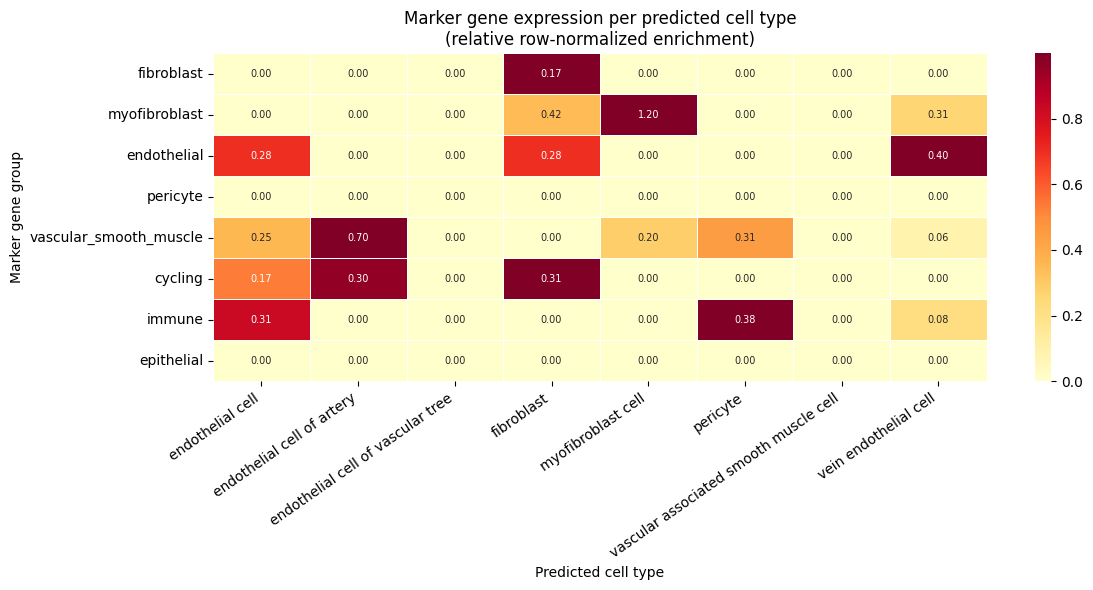

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(
    marker_df_norm,
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.4,
    annot=marker_df.round(2),
    fmt=".2f",
    annot_kws={"size": 7},
)

ax.set_title("Marker gene expression per predicted cell type\n(relative row-normalized enrichment)")
ax.set_xlabel("Predicted cell type")
ax.set_ylabel("Marker gene group")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
savefig("marker_gene_heatmap.png")
plt.show()

## 3 · Confidence scoring

In [7]:
predictions = predictions.copy()

# Best cosine similarity from Notebook 03.
predictions["confidence"] = predictions["best_similarity"]

# Margin between the highest and second-highest prototype score.
if sim_df.shape[1] < 2:
    raise ValueError("Need at least two prototype columns to compute margin.")

sorted_scores = np.sort(sim_df.values, axis=1)
margin = sorted_scores[:, -1] - sorted_scores[:, -2]

predictions["margin"] = margin

predictions["low_similarity"] = predictions["confidence"] < CONFIDENCE_THRESHOLD
predictions["low_margin"] = predictions["margin"] < MARGIN_THRESHOLD
predictions["low_confidence"] = predictions["low_similarity"] | predictions["low_margin"]

n_low = int(predictions["low_confidence"].sum())
n_total = len(predictions)

print(f"Low-confidence cells: {n_low} / {n_total} ({100 * n_low / max(n_total, 1):.1f}%)")
print(f"  Low similarity (< {CONFIDENCE_THRESHOLD}): {predictions['low_similarity'].sum()}")
print(f"  Low margin (< {MARGIN_THRESHOLD}): {predictions['low_margin'].sum()}")

print("\nLow-confidence breakdown by predicted type:")
print(predictions[predictions["low_confidence"]]["predicted_cell_type"].value_counts())

display(predictions.head())

Low-confidence cells: 82 / 82 (100.0%)
  Low similarity (< 0.5): 82
  Low margin (< 0.05): 82

Low-confidence breakdown by predicted type:
predicted_cell_type
endothelial cell                          30
vein endothelial cell                     16
fibroblast                                12
pericyte                                   8
endothelial cell of artery                 5
myofibroblast cell                         5
endothelial cell of vascular tree          4
vascular associated smooth muscle cell     2
Name: count, dtype: int64


,predicted_cell_type,best_similarity,confidence,margin,low_similarity,low_margin,low_confidence
cell_1,endothelial cell of artery,0.123726,0.123726,0.000517,True,True,True
cell_2,fibroblast,0.089567,0.089567,0.003142,True,True,True
cell_3,endothelial cell,0.154247,0.154247,0.011477,True,True,True
cell_4,fibroblast,0.100240,0.100240,0.002013,True,True,True
cell_5,endothelial cell,0.098915,0.098915,0.001955,True,True,True


Saved → ../outputs/confidence_histogram.png


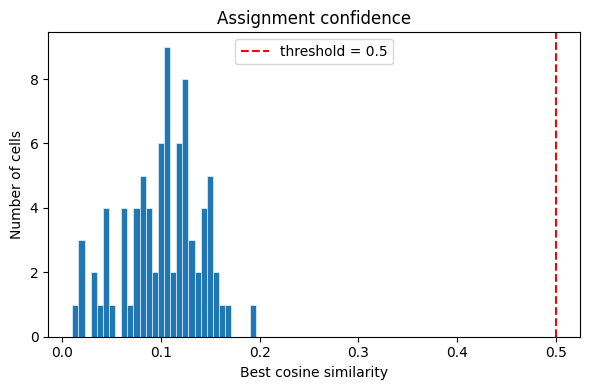

Saved → ../outputs/margin_histogram.png


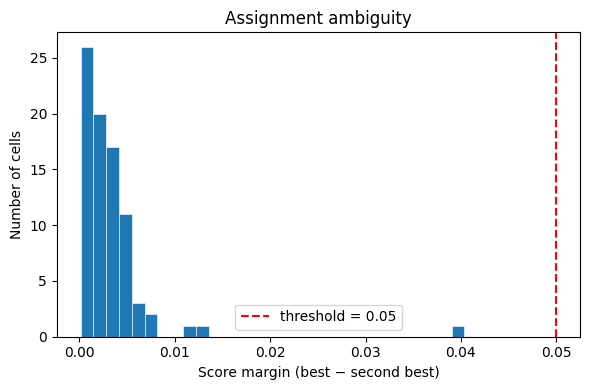

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(predictions["confidence"], bins=30, edgecolor="white", linewidth=0.4)
ax.axvline(CONFIDENCE_THRESHOLD, color="red", linestyle="--", label=f"threshold = {CONFIDENCE_THRESHOLD}")
ax.set_xlabel("Best cosine similarity")
ax.set_ylabel("Number of cells")
ax.set_title("Assignment confidence")
ax.legend()
plt.tight_layout()
savefig("confidence_histogram.png")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(predictions["margin"], bins=30, edgecolor="white", linewidth=0.4)
ax.axvline(MARGIN_THRESHOLD, color="red", linestyle="--", label=f"threshold = {MARGIN_THRESHOLD}")
ax.set_xlabel("Score margin (best − second best)")
ax.set_ylabel("Number of cells")
ax.set_title("Assignment ambiguity")
ax.legend()
plt.tight_layout()
savefig("margin_histogram.png")
plt.show()

In [ ]:
# 3.1. Load image crop for correction and spatial plots

IMAGE_PATH = find_first_morphology_image(MORPHOLOGY_DIR)
print(f"Using image: {IMAGE_PATH}")

img_crop, start_x, start_y = load_center_crop(IMAGE_PATH, CROP_SIZE)

print("Image crop shape:", img_crop.shape)

Using image: ../data/morphology_focus/morphology_focus_0000.ome.tif
Image crop shape: (512, 512)


In [ ]:
# Biological correction / ablation pipeline

from sklearn.metrics.pairwise import cosine_similarity as cos_sim

RUN_RESEGMENTATION = True
RETRY_DIAMETER = 20
PATCH_SIZE = 80

ASSIGNED_TRANSCRIPTS_PATH = OUTPUT_DIR / "assigned_transcripts_crop.csv"
ABLATION_RESULTS_PATH = OUTPUT_DIR / "ablation_results.csv"
REFINED_PATH = OUTPUT_DIR / "cell_type_predictions_refined.csv"

if not ASSIGNED_TRANSCRIPTS_PATH.exists():
    raise FileNotFoundError(f"Missing assigned transcripts file: {ASSIGNED_TRANSCRIPTS_PATH}")

assigned_tx = pd.read_csv(ASSIGNED_TRANSCRIPTS_PATH)

required_cols = {"x_local", "y_local", "feature_name"}
missing_cols = required_cols - set(assigned_tx.columns)

if missing_cols:
    raise ValueError(f"assigned_transcripts_crop.csv is missing columns: {missing_cols}")

flagged = predictions[predictions["low_confidence"]].copy()

print(f"Low-confidence cells selected for correction: {len(flagged)}")

proto_values = prototypes.values
shared_genes = list(prototypes.columns)

refined_predictions = predictions.copy()
ablation_rows = []

if RUN_RESEGMENTATION and CELLPOSE_AVAILABLE:
    model = models.CellposeModel(gpu=True)

    for cell_id_str, row in flagged.iterrows():
        cell_id = parse_cell_id(cell_id_str)

        if cell_id is None:
            continue

        before_score = row["best_similarity"]
        before_type = row["predicted_cell_type"]

        ys, xs = np.where(masks == cell_id)

        if len(ys) == 0:
            ablation_rows.append({
                "cell_id": cell_id_str,
                "before_score": before_score,
                "after_score": before_score,
                "before_type": before_type,
                "after_type": before_type,
                "accepted": False,
                "decision": "rejected_no_mask_pixels",
                "improvement": 0.0,
            })
            continue

        cy, cx = int(ys.mean()), int(xs.mean())

        y0 = max(0, cy - PATCH_SIZE // 2)
        y1 = min(CROP_SIZE, cy + PATCH_SIZE // 2)
        x0 = max(0, cx - PATCH_SIZE // 2)
        x1 = min(CROP_SIZE, cx + PATCH_SIZE // 2)

        patch = img_crop[y0:y1, x0:x1]

        if patch.size == 0:
            ablation_rows.append({
                "cell_id": cell_id_str,
                "before_score": before_score,
                "after_score": before_score,
                "before_type": before_type,
                "after_type": before_type,
                "accepted": False,
                "decision": "rejected_empty_patch",
                "improvement": 0.0,
            })
            continue

        patch_masks, _, _ = model.eval(
            patch,
            diameter=RETRY_DIAMETER,
            batch_size=1
        )

        patch_cy = (y1 - y0) // 2
        patch_cx = (x1 - x0) // 2
        new_cell_id = patch_masks[patch_cy, patch_cx]

        if new_cell_id == 0:
            ablation_rows.append({
                "cell_id": cell_id_str,
                "before_score": before_score,
                "after_score": before_score,
                "before_type": before_type,
                "after_type": before_type,
                "accepted": False,
                "decision": "rejected_no_center_cell",
                "improvement": 0.0,
            })
            continue

        patch_tx = assigned_tx[
            (assigned_tx["x_local"] >= x0) &
            (assigned_tx["x_local"] < x1) &
            (assigned_tx["y_local"] >= y0) &
            (assigned_tx["y_local"] < y1)
        ].copy()

        if len(patch_tx) == 0:
            ablation_rows.append({
                "cell_id": cell_id_str,
                "before_score": before_score,
                "after_score": before_score,
                "before_type": before_type,
                "after_type": before_type,
                "accepted": False,
                "decision": "rejected_no_transcripts",
                "improvement": 0.0,
            })
            continue

        patch_tx["patch_cell"] = patch_masks[
            (patch_tx["y_local"] - y0).astype(int).clip(0, patch_masks.shape[0] - 1),
            (patch_tx["x_local"] - x0).astype(int).clip(0, patch_masks.shape[1] - 1),
        ]

        new_cell_tx = patch_tx[patch_tx["patch_cell"] == new_cell_id]

        if len(new_cell_tx) == 0:
            ablation_rows.append({
                "cell_id": cell_id_str,
                "before_score": before_score,
                "after_score": before_score,
                "before_type": before_type,
                "after_type": before_type,
                "accepted": False,
                "decision": "rejected_no_transcripts_in_new_cell",
                "improvement": 0.0,
            })
            continue

        new_expr = (
            new_cell_tx["feature_name"]
            .value_counts()
            .reindex(shared_genes, fill_value=0)
            .values
            .reshape(1, -1)
        )

        if new_expr.sum() == 0:
            ablation_rows.append({
                "cell_id": cell_id_str,
                "before_score": before_score,
                "after_score": before_score,
                "before_type": before_type,
                "after_type": before_type,
                "accepted": False,
                "decision": "rejected_zero_expression",
                "improvement": 0.0,
            })
            continue

        new_expr_norm = normalize(new_expr, norm="l2")
        scores = cos_sim(new_expr_norm, proto_values)[0]

        after_score = scores.max()
        after_type = prototypes.index[scores.argmax()]
        after_margin = np.sort(scores)[-1] - np.sort(scores)[-2]

        accepted = after_score > before_score
        improvement = after_score - before_score

        if accepted:
            refined_predictions.loc[cell_id_str, "predicted_cell_type"] = after_type
            refined_predictions.loc[cell_id_str, "best_similarity"] = after_score
            refined_predictions.loc[cell_id_str, "confidence"] = after_score
            refined_predictions.loc[cell_id_str, "margin"] = after_margin
            refined_predictions.loc[cell_id_str, "low_similarity"] = after_score < CONFIDENCE_THRESHOLD
            refined_predictions.loc[cell_id_str, "low_margin"] = after_margin < MARGIN_THRESHOLD
            refined_predictions.loc[cell_id_str, "low_confidence"] = (
                refined_predictions.loc[cell_id_str, "low_similarity"] or
                refined_predictions.loc[cell_id_str, "low_margin"]
            )

        ablation_rows.append({
            "cell_id": cell_id_str,
            "before_score": before_score,
            "after_score": after_score if accepted else before_score,
            "candidate_after_score": after_score,
            "before_type": before_type,
            "after_type": after_type if accepted else before_type,
            "candidate_after_type": after_type,
            "accepted": accepted,
            "decision": "accepted_improved" if accepted else "rejected_no_improvement",
            "improvement": improvement if accepted else 0.0,
        })

else:
    print("Re-segmentation skipped. Creating baseline-only ablation table.")

    for cell_id_str, row in flagged.iterrows():
        ablation_rows.append({
            "cell_id": cell_id_str,
            "before_score": row["best_similarity"],
            "after_score": row["best_similarity"],
            "candidate_after_score": row["best_similarity"],
            "before_type": row["predicted_cell_type"],
            "after_type": row["predicted_cell_type"],
            "candidate_after_type": row["predicted_cell_type"],
            "accepted": False,
            "decision": "not_run",
            "improvement": 0.0,
        })

ablation_df = pd.DataFrame(ablation_rows)

ablation_df.to_csv(ABLATION_RESULTS_PATH, index=False)
refined_predictions.to_csv(REFINED_PATH)

print(f"Saved ablation results → {ABLATION_RESULTS_PATH}")
print(f"Saved refined predictions → {REFINED_PATH}")

print("\nAblation decision counts:")
print(ablation_df["decision"].value_counts())

Low-confidence cells selected for correction: 82


/Users/mahsa/Projects/Computational-Genomics-Project/.venv/lib/python3.10/site-packages/cellpose/dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


Saved ablation results → ../outputs/ablation_results.csv
Saved refined predictions → ../outputs/cell_type_predictions_refined.csv

Ablation decision counts:
decision
rejected_no_improvement    48
accepted_improved          19
rejected_no_center_cell    15
Name: count, dtype: int64


In [ ]:
# Ablation metrics

before_scores = predictions["best_similarity"]
after_scores = refined_predictions["best_similarity"]

low_before = predictions["low_confidence"].sum()
low_after = refined_predictions["low_confidence"].sum()

n_total = len(predictions)
n_flagged = len(ablation_df)
n_accepted = ablation_df["accepted"].sum()
n_rejected = n_flagged - n_accepted

improved_scores = ablation_df.loc[ablation_df["accepted"], "improvement"]

metrics = {
    "total_segmented_cells": n_total,
    "mean_cosine_before": before_scores.mean(),
    "mean_cosine_after": after_scores.mean(),
    "median_cosine_before": before_scores.median(),
    "median_cosine_after": after_scores.median(),
    "std_cosine_before": before_scores.std(),
    "std_cosine_after": after_scores.std(),
    "low_confidence_before": low_before,
    "low_confidence_after": low_after,
    "percent_low_confidence_before": 100 * low_before / n_total,
    "percent_low_confidence_after": 100 * low_after / n_total,
    "cells_considered_for_correction": n_flagged,
    "cells_improved": n_accepted,
    "percent_improved_of_flagged": 100 * n_accepted / max(n_flagged, 1),
    "cells_rejected_or_unchanged": n_rejected,
    "average_cosine_improvement_among_improved": improved_scores.mean() if len(improved_scores) else 0,
    "max_cosine_improvement": improved_scores.max() if len(improved_scores) else 0,
}

metrics_df = pd.DataFrame([metrics])
metrics_path = OUTPUT_DIR / "ablation_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

display(metrics_df.T.rename(columns={0: "value"}))

print(f"Saved ablation metrics → {metrics_path}")

,value
total_segmented_cells,82.000000
mean_cosine_before,0.100875
mean_cosine_after,0.101349
median_cosine_before,0.103892
median_cosine_after,0.103892
std_cosine_before,0.039028
std_cosine_after,0.038841
low_confidence_before,82.000000
low_confidence_after,82.000000
percent_low_confidence_before,100.000000


Saved ablation metrics → ../outputs/ablation_metrics.csv


## 4 · Spatial confidence map

Saved → ../outputs/confidence_map.png


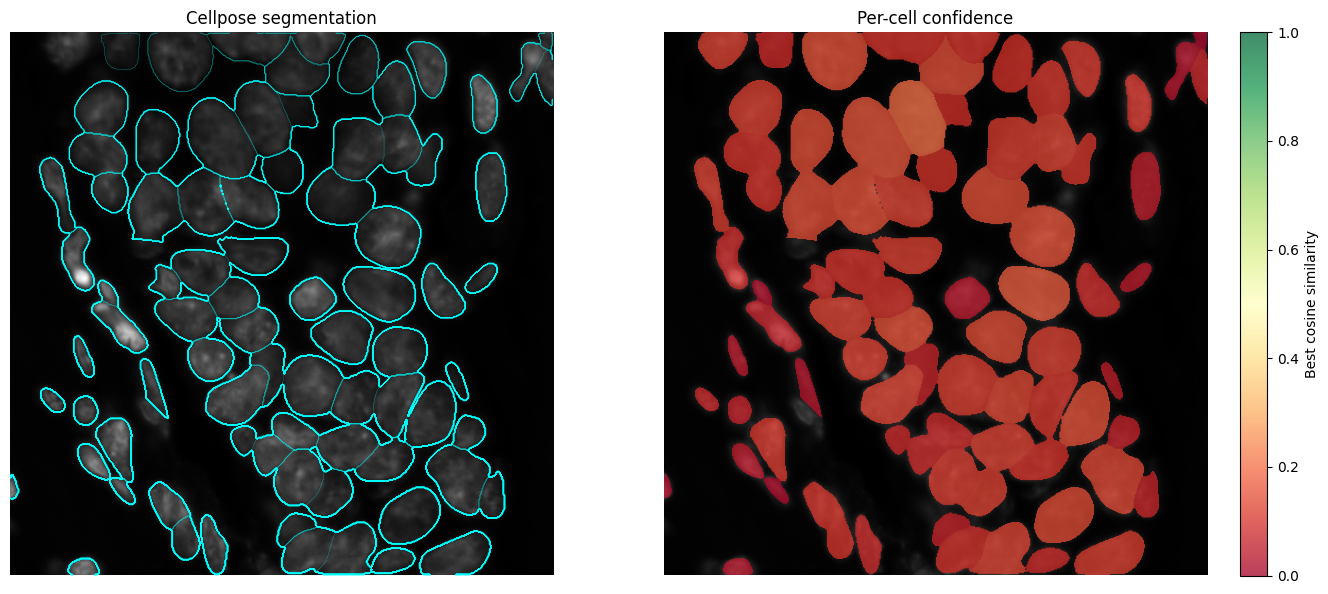

In [12]:
confidence_map = np.zeros(masks.shape, dtype=float)
margin_map = np.zeros(masks.shape, dtype=float)
low_conf_map = np.zeros(masks.shape, dtype=float)

for cell_id_str, row in predictions.iterrows():
    cell_id = parse_cell_id(cell_id_str)
    if cell_id is None:
        continue

    confidence_map[masks == cell_id] = row["confidence"]
    margin_map[masks == cell_id] = row["margin"]
    low_conf_map[masks == cell_id] = 1.0 if row["low_confidence"] else 0.0

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img_crop, cmap="gray")
levels = np.unique(masks)
levels = levels[levels > 0]
if len(levels):
    axes[0].contour(masks, levels=levels, linewidths=0.3, colors="cyan", alpha=0.5)
axes[0].set_title("Cellpose segmentation")
axes[0].axis("off")

axes[1].imshow(img_crop, cmap="gray")
conf_masked = np.ma.masked_where(masks == 0, confidence_map)
im = axes[1].imshow(conf_masked, cmap="RdYlGn", vmin=0, vmax=1, alpha=0.75)
plt.colorbar(im, ax=axes[1], fraction=0.046, label="Best cosine similarity")
axes[1].set_title("Per-cell confidence")
axes[1].axis("off")

plt.tight_layout()
savefig("confidence_map.png")
plt.show()

## 5 · Flagged cells overlay

Saved → ../outputs/flagged_cells_overlay.png


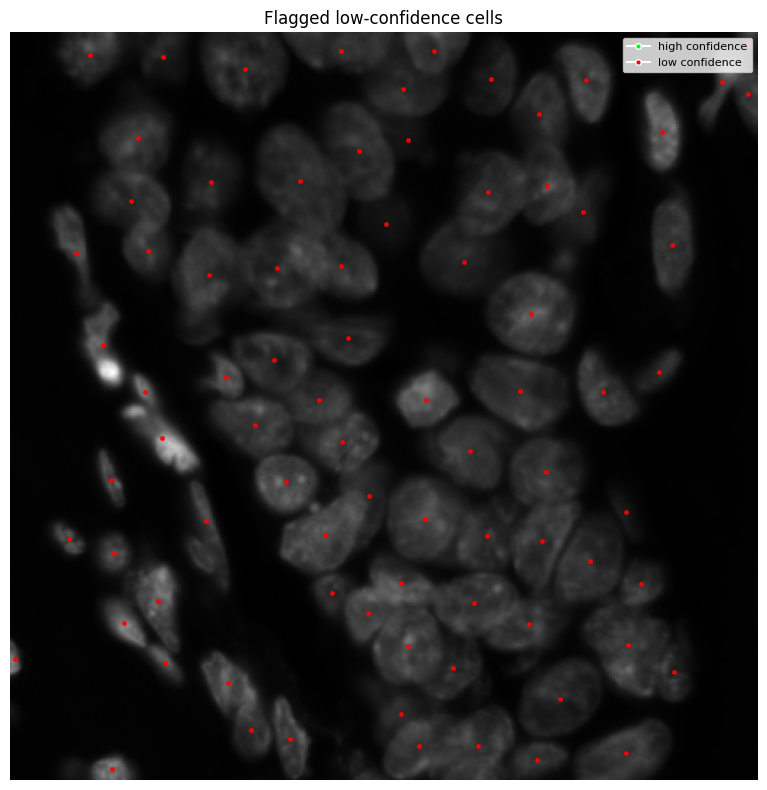

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_crop, cmap="gray")

for cell_id_str, row in predictions.iterrows():
    cell_id = parse_cell_id(cell_id_str)
    if cell_id is None:
        continue

    ys, xs = np.where(masks == cell_id)
    if len(ys) == 0:
        continue

    color = "red" if row["low_confidence"] else "lime"
    ax.plot(xs.mean(), ys.mean(), ".", color=color, markersize=5, alpha=0.85)

from matplotlib.lines import Line2D

ax.legend(
    handles=[
        Line2D([0], [0], marker=".", color="w", markerfacecolor="lime", markersize=8, label="high confidence"),
        Line2D([0], [0], marker=".", color="w", markerfacecolor="red", markersize=8, label="low confidence"),
    ],
    loc="upper right",
    fontsize=8,
)

ax.set_title("Flagged low-confidence cells")
ax.axis("off")
plt.tight_layout()
savefig("flagged_cells_overlay.png")
plt.show()

## 6 · Save refined predictions

In [14]:
refined_predictions = predictions.copy()

refined_predictions.to_csv(REFINED_PATH)
print(f"Saved refined predictions → {REFINED_PATH}")

Saved refined predictions → ../outputs/cell_type_predictions_refined.csv


## 7 · Optional experimental post-processing: re-segment low-confidence cells

This section is optional and intentionally disabled by default.

It attempts to crop around each low-confidence cell, re-run Cellpose with a different diameter, and compare the new expression profile to the prototypes. This is experimental and may be slow or fragile, so the core project should not depend on it.


In [15]:
if RUN_RESEGMENTATION and CELLPOSE_AVAILABLE:
    require_file(ASSIGNED_TRANSCRIPTS_PATH, "assigned transcript table")

    assigned_tx = pd.read_csv(ASSIGNED_TRANSCRIPTS_PATH)
    model = models.CellposeModel(gpu=True)

    proto_values = prototypes.values
    shared_genes = list(prototypes.columns)

    flagged = predictions[predictions["low_confidence"]].copy()
    print(f"Re-segmenting {len(flagged)} low-confidence cells at diameter={RETRY_DIAMETER}...")

    improved = 0
    refined_predictions = predictions.copy()

    for cell_id_str in flagged.index:
        cell_id = parse_cell_id(cell_id_str)
        if cell_id is None:
            continue

        ys, xs = np.where(masks == cell_id)
        if len(ys) == 0:
            continue

        cy, cx = int(ys.mean()), int(xs.mean())

        y0 = max(0, cy - PATCH_SIZE // 2)
        y1 = min(CROP_SIZE, cy + PATCH_SIZE // 2)
        x0 = max(0, cx - PATCH_SIZE // 2)
        x1 = min(CROP_SIZE, cx + PATCH_SIZE // 2)

        patch = img_crop[y0:y1, x0:x1]
        if patch.size == 0:
            continue

        patch_masks, _, _ = model.eval(patch, diameter=RETRY_DIAMETER, batch_size=1)

        patch_cy = (y1 - y0) // 2
        patch_cx = (x1 - x0) // 2
        new_cell_id = patch_masks[patch_cy, patch_cx]

        if new_cell_id == 0:
            continue

        patch_tx = assigned_tx[
            (assigned_tx["x_local"] >= x0) & (assigned_tx["x_local"] < x1) &
            (assigned_tx["y_local"] >= y0) & (assigned_tx["y_local"] < y1)
        ].copy()

        if len(patch_tx) == 0:
            continue

        patch_tx["patch_cell"] = patch_masks[
            (patch_tx["y_local"] - y0).astype(int).clip(0, patch_masks.shape[0] - 1),
            (patch_tx["x_local"] - x0).astype(int).clip(0, patch_masks.shape[1] - 1),
        ]

        cell_tx = patch_tx[patch_tx["patch_cell"] == new_cell_id]

        if len(cell_tx) == 0:
            continue

        gene_col = "feature_name"
        if gene_col not in cell_tx.columns:
            raise ValueError(f"Expected '{gene_col}' in assigned transcript table.")

        new_expr = (
            cell_tx[gene_col]
            .value_counts()
            .reindex(shared_genes, fill_value=0)
            .values
            .reshape(1, -1)
        )

        if new_expr.sum() == 0:
            continue

        new_expr_norm = normalize(new_expr, norm="l2")
        scores = cos_sim(new_expr_norm, proto_values)[0]

        best_score = scores.max()
        best_type = prototypes.index[scores.argmax()]
        new_margin = np.sort(scores)[-1] - np.sort(scores)[-2]

        if best_score > predictions.loc[cell_id_str, "best_similarity"]:
            refined_predictions.loc[cell_id_str, "predicted_cell_type"] = best_type
            refined_predictions.loc[cell_id_str, "best_similarity"] = best_score
            refined_predictions.loc[cell_id_str, "confidence"] = best_score
            refined_predictions.loc[cell_id_str, "margin"] = new_margin
            refined_predictions.loc[cell_id_str, "low_similarity"] = best_score < CONFIDENCE_THRESHOLD
            refined_predictions.loc[cell_id_str, "low_margin"] = new_margin < MARGIN_THRESHOLD
            refined_predictions.loc[cell_id_str, "low_confidence"] = (
                refined_predictions.loc[cell_id_str, "low_similarity"] or
                refined_predictions.loc[cell_id_str, "low_margin"]
            )
            improved += 1

    print(f"Improved: {improved} / {len(flagged)} low-confidence cells")
    refined_predictions.to_csv(REFINED_PATH)
    print(f"Saved refined predictions → {REFINED_PATH}")

else:
    print("Re-segmentation skipped.")
    print("Set RUN_RESEGMENTATION = True if you want to run this experimental section.")

Re-segmenting 82 low-confidence cells at diameter=20...
Improved: 19 / 82 low-confidence cells
Saved refined predictions → ../outputs/cell_type_predictions_refined.csv


## 8 · Before / after comparison

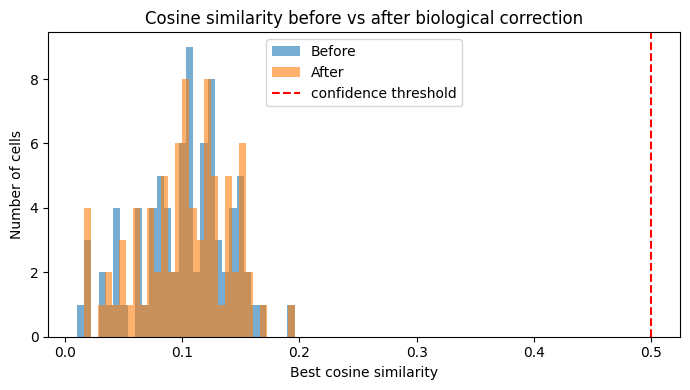

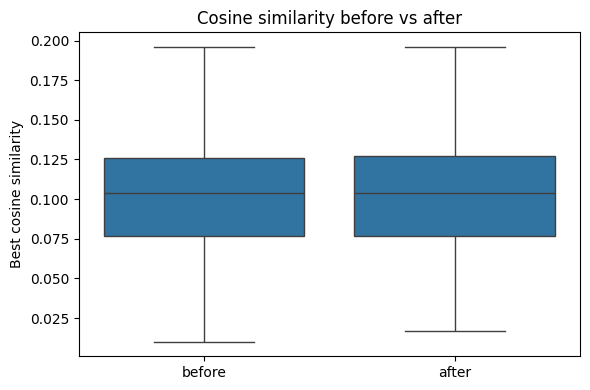

In [17]:
comparison_df = pd.DataFrame({
    "before": predictions["best_similarity"],
    "after": refined_predictions["best_similarity"],
})

comparison_long = comparison_df.reset_index().melt(
    id_vars="index",
    value_vars=["before", "after"],
    var_name="condition",
    value_name="cosine_similarity"
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(comparison_df["before"], bins=30, alpha=0.6, label="Before")
ax.hist(comparison_df["after"], bins=30, alpha=0.6, label="After")
ax.axvline(CONFIDENCE_THRESHOLD, color="red", linestyle="--", label="confidence threshold")
ax.set_xlabel("Best cosine similarity")
ax.set_ylabel("Number of cells")
ax.set_title("Cosine similarity before vs after biological correction")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cosine_before_after_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(
    data=comparison_long,
    x="condition",
    y="cosine_similarity",
    ax=ax
)
ax.set_title("Cosine similarity before vs after")
ax.set_xlabel("")
ax.set_ylabel("Best cosine similarity")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cosine_before_after_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
(refined_predictions["best_similarity"] != predictions["best_similarity"]).sum()

np.int64(19)

## 9 · Final sanity checks

In [19]:
ablation_df["accepted"].value_counts()

accepted
False    63
True     19
Name: count, dtype: int64

In [20]:
diff = refined_predictions["best_similarity"] - predictions["best_similarity"]

print(diff.describe())
print("Mean improvement:", diff.mean())
print("Max improvement:", diff.max())

count    82.000000
mean      0.000474
std       0.001434
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.009165
Name: best_similarity, dtype: float64
Mean improvement: 0.00047446526184854364
Max improvement: 0.009164527693295456


In [ ]:
print("Notebook 04 sanity check")
print("------------------------")
print(f"Cells evaluated:              {len(cells):,}")
print(f"Genes per cell:               {cells.shape[1]:,}")
print(f"Prototype cell types:         {prototypes.shape[0]:,}")
print(f"Prediction rows:              {len(predictions):,}")
print(f"Low-confidence cells:         {predictions['low_confidence'].sum():,}")
print(f"Refined prediction path:      {REFINED_PATH}")
print(f"Marker heatmap path:          {OUTPUT_DIR / 'marker_gene_heatmap.png'}")
print(f"Confidence map path:          {OUTPUT_DIR / 'confidence_map.png'}")
print(f"Flagged overlay path:         {OUTPUT_DIR / 'flagged_cells_overlay.png'}")

assert len(cells) == len(predictions)
assert cells.shape[1] == prototypes.shape[1]
assert REFINED_PATH.exists()

print("\nNotebook 04 completed successfully.")

Notebook 04 sanity check
------------------------
Cells evaluated:              82
Genes per cell:               5,054
Prototype cell types:         8
Prediction rows:              82
Low-confidence cells:         82
Refined prediction path:      ../outputs/cell_type_predictions_refined.csv
Marker heatmap path:          ../outputs/marker_gene_heatmap.png
Confidence map path:          ../outputs/confidence_map.png
Flagged overlay path:         ../outputs/flagged_cells_overlay.png

Notebook 04 completed successfully.
